# 02 — Feature Engineering

Input: `data/processed/listings_clean.parquet`
Output: `data/processed/listings_features.parquet` — model-ready table

## Engineered feature families
| Family | Examples | Rationale |
|---|---|---|
| **Distance** | `dist_city_center_km`, `dist_temple_bar_km`, `dist_airport_km` | Coarse `neighbourhood_cleansed` has only 4 values — geodesic distances give continuous spatial signal |
| **Amenities** | `has_wifi`, `has_self_checkin`, `amenities_count` | Parsed from JSON-like string; flags chosen for high signal × prevalence |
| **Host** | `host_tenure_years`, `is_commercial_host` | Tenure proxies trust; portfolio size proxies pricing strategy |
| **Text** | `desc_length`, `name_caps_ratio` | Effort/quality signal of listing |


In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_processed, save_processed
from src.features import build_features, ANCHORS

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110


In [2]:
df = load_processed('listings_clean')
print(f'Loaded clean listings: {df.shape}')

Loaded clean listings: (6945, 80)


## 1. Build features (full pipeline)

In [3]:
# Drop rows without price (cannot be used for supervised modeling)
df = df.dropna(subset=['price']).copy()

feat = build_features(df)
print(f'Features added; new shape: {feat.shape}')
print(f'Added {feat.shape[1] - df.shape[1]} new columns')

Features added; new shape: (5244, 111)
Added 31 new columns


## 2. Distance features — spatial signal

In [4]:
dist_cols = [c for c in feat.columns if c.startswith('dist_')]
print('Distance features:', dist_cols)
feat[dist_cols].describe().round(2)

Distance features: ['dist_city_center_km', 'dist_temple_bar_km', 'dist_trinity_college_km', 'dist_guinness_km', 'dist_airport_km', 'dist_ifsc_km']


,dist_city_center_km,dist_temple_bar_km,dist_trinity_college_km,dist_guinness_km,dist_airport_km,dist_ifsc_km
count,5244.00,5244.00,5244.00,5244.00,5244.00,5244.00
mean,5.42,5.38,5.42,5.78,10.29,5.65
std,5.23,5.29,5.27,5.21,4.11,5.13
min,0.02,0.02,0.17,0.05,1.90,0.04
25%,1.54,1.51,1.56,2.08,7.75,1.90
50%,3.22,3.06,3.01,3.60,9.09,3.51
75%,8.86,8.82,8.74,8.54,11.90,8.59
max,30.17,30.70,30.78,31.34,25.62,30.13


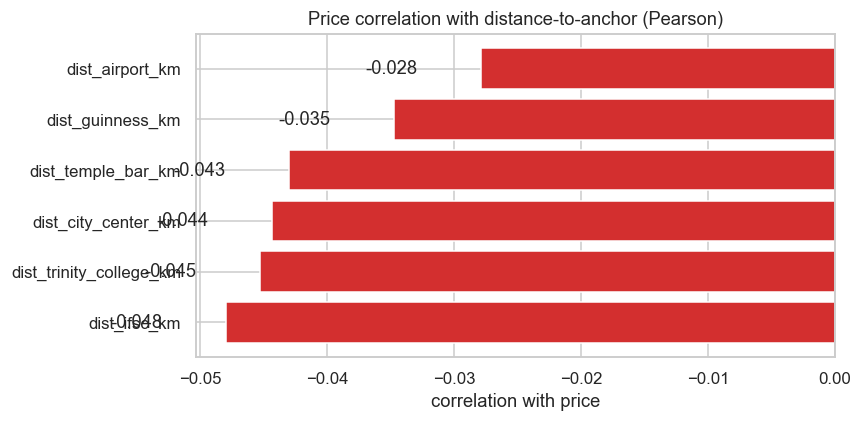

In [5]:
# Correlation of each distance with price
corrs = feat[dist_cols + ['price']].corr()['price'].drop('price').sort_values()
fig, ax = plt.subplots(figsize=(8,4))
colors = ['#D32F2F' if c < 0 else '#388E3C' for c in corrs]
ax.barh(corrs.index, corrs.values, color=colors)
for i, v in enumerate(corrs.values):
    ax.text(v + (0.005 if v>0 else -0.005), i, f'{v:+.3f}',
            va='center', ha='left' if v>0 else 'right')
ax.axvline(0, color='black', lw=0.5)
ax.set(title='Price correlation with distance-to-anchor (Pearson)',
       xlabel='correlation with price')
plt.tight_layout()
plt.savefig('../reports/figures/04_distance_corr.png', dpi=140, bbox_inches='tight')
plt.show()

Negative correlation with `dist_city_center_km` confirms the obvious:
closer to centre → higher price. The strength of each distance signal varies —
the model will pick the most informative ones via tree-based feature importance.

## 3. Amenity flags — which features actually move price?

In [6]:
amen_flags = [c for c in feat.columns if c.startswith('has_')]
amen_summary = pd.DataFrame({
    'prevalence_%': (feat[amen_flags].mean() * 100).round(1),
    'mean_price_with':    [feat.loc[feat[c]==1, 'price'].mean() for c in amen_flags],
    'mean_price_without': [feat.loc[feat[c]==0, 'price'].mean() for c in amen_flags],
}).round(1)
amen_summary['price_lift_€'] = (amen_summary['mean_price_with'] - amen_summary['mean_price_without']).round(1)
amen_summary['price_lift_%'] = (amen_summary['price_lift_€'] / amen_summary['mean_price_without'] * 100).round(1)
amen_summary.sort_values('price_lift_%', ascending=False)

,prevalence_%,mean_price_with,mean_price_without,price_lift_€,price_lift_%
has_washer,78.6,218.8,151.8,67.0,44.1
has_kitchen,83.3,214.8,152.8,62.0,40.6
has_pets_allowed,11.1,267.0,196.7,70.3,35.7
has_pool,1.0,244.4,204.1,40.3,19.7
has_tv,3.5,237.1,203.3,33.8,16.6
has_gym,2.2,228.6,203.9,24.7,12.1
has_self_checkin,44.4,215.5,195.7,19.8,10.1
has_dryer,73.4,208.0,194.9,13.1,6.7
has_heating,80.2,206.4,196.9,9.5,4.8
has_aircon,5.4,212.3,204.1,8.2,4.0


> ⚠️ **Lift is descriptive, not causal.** A pool correlates with higher price
because pools appear in larger / pricier properties — not because adding a pool
adds €X. The ML model will disentangle this via multivariate effects.

## 4. Host features

                          median   mean  count
Individual (<5 listings)   129.0  198.9   3834
Commercial (5+ listings)   158.0  219.6   1410


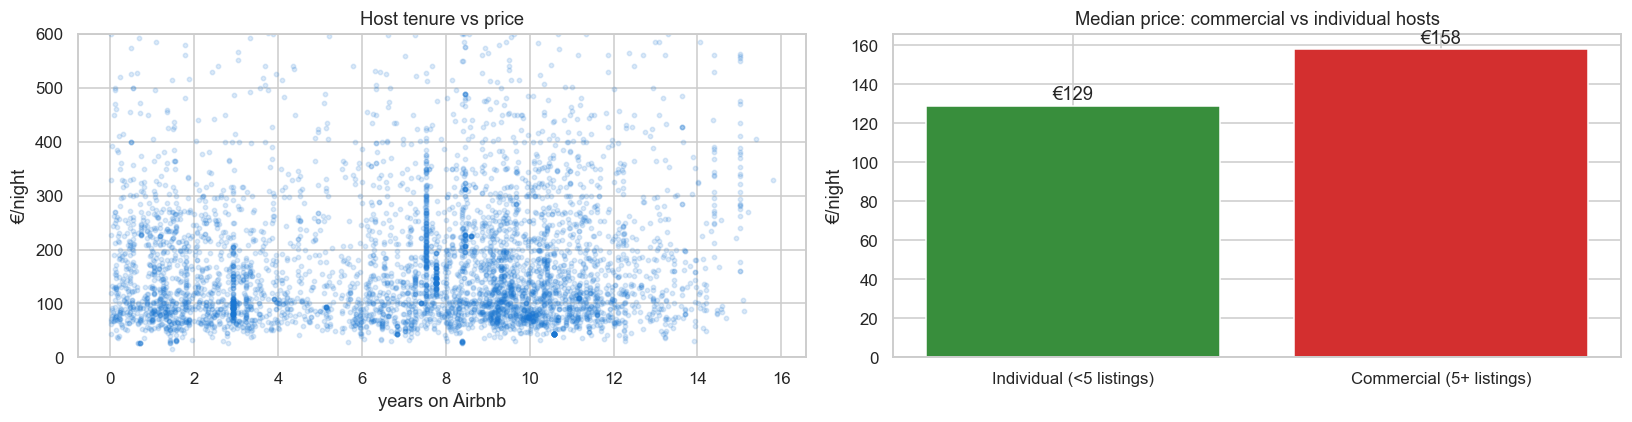

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Tenure vs price
sub = feat.dropna(subset=['host_tenure_years'])
axes[0].scatter(sub['host_tenure_years'], sub['price'], alpha=0.15, s=8, color='#1976D2')
axes[0].set(title='Host tenure vs price', xlabel='years on Airbnb', ylabel='€/night', ylim=(0, 600))

# Commercial vs individual
commercial_price = feat.groupby('is_commercial_host')['price'].agg(['median','mean','count'])
commercial_price.index = ['Individual (<5 listings)', 'Commercial (5+ listings)']
print(commercial_price.round(1))

axes[1].bar(commercial_price.index, commercial_price['median'],
            color=['#388E3C', '#D32F2F'])
for i, v in enumerate(commercial_price['median']):
    axes[1].text(i, v+3, f'€{v:.0f}', ha='center')
axes[1].set(title='Median price: commercial vs individual hosts', ylabel='€/night')

plt.tight_layout()
plt.savefig('../reports/figures/05_host_features.png', dpi=140, bbox_inches='tight')
plt.show()

## 5. Persist for modeling

In [8]:
# Keep only modeling-relevant columns to make downstream notebooks lean
KEEP = [
    # target
    'id','price',
    # categorical
    'room_type','property_type','neighbourhood_cleansed','neighbourhood_norm',
    # numeric core
    'accommodates','bedrooms','beds','bathrooms',
    'minimum_nights','availability_30','availability_365',
    'number_of_reviews','reviews_per_month','review_scores_rating',
    'host_response_rate','host_acceptance_rate','host_tenure_years',
    'calculated_host_listings_count','is_commercial_host','is_multi_listing_host',
    # booleans
    'host_is_superhost','instant_bookable',
    # engineered
    'amenities_count','name_length','desc_length','name_caps_ratio',
    # geo
    'latitude','longitude',
] + [c for c in feat.columns if c.startswith('dist_')] \
  + [c for c in feat.columns if c.startswith('has_')]

KEEP = [c for c in KEEP if c in feat.columns]
model_df = feat[KEEP].copy()
print(f'Model-ready shape: {model_df.shape}')

save_processed(model_df, 'listings_features', fmt='parquet')
print('✅ Saved: data/processed/listings_features.parquet')

Model-ready shape: (5244, 54)
✅ Saved: data/processed/listings_features.parquet
